###Project Summary -
The financial industry has witnessed a significant rise in fraudulent activities and credit risks over the past decade, making fraud detection and credit risk assessment critical areas of focus for banks and financial institutions. In this project, we analyze a large-scale dataset provided by Paisabazaar, which includes customer demographics, financial details, credit utilization patterns, and payment behaviors. By conducting Exploratory Data Analysis (EDA) and visualizations, the goal is to uncover key insights that can help detect fraudulent behavior, assess financial risk, and strengthen customer credit profiling.

The dataset consists of 81782 records with 28 attributes related to customer identity, financial history, and credit score. Key columns include Annual Income, Monthly Inhand Salary, Number of Bank Accounts, Number of Credit Cards, Interest Rate, Outstanding Debt, Credit Utilization Ratio, Credit History Age, Payment Behavior, and Credit Score. These variables are essential indicators of financial health and are widely used in risk modeling and fraud detection systems. The presence of demographic details such as Age, Occupation, and SSN adds an additional layer for identifying potential fraud cases, such as multiple accounts linked to the same identity or unrealistic financial behaviors.

The first step of the project involves data cleaning and preprocessing. Although the dataset does not contain missing values, duplicate entries or repeated customer records across multiple months are also examined to ensure data integrity.

The next stage focuses on Exploratory Data Analysis (EDA). Here, we investigate how different features relate to fraudulent or risky financial behavior. For instance, the relationship between Credit Utilization Ratio and Credit Score can reveal whether customers who use higher proportions of their available credit are more likely to have poor scores. Similarly, analysis of Number of Delayed Payments and Delay from Due Date can highlight patterns of financial irresponsibility, which are often precursors to fraud or default. Visualizations such as histograms, boxplots, heatmaps, and correlation matrices help identify trends, anomalies, and feature interdependencies.

One of the core aspects of this project is fraud analysis. Fraudulent behavior often manifests in unrealistic or contradictory patterns in financial data. For example, a customer with a low annual income but multiple credit cards, high loan counts, and excessive monthly spending could indicate suspicious activity. Similarly, sudden changes in Credit Limit, unusually high Credit Inquiries, or inconsistent Payment Behavior can serve as red flags. By combining statistical analysis and visual exploration, we aim to highlight such irregularities.

Another key outcome of this project is credit risk profiling. The dataset contains a labeled feature, Credit Score, categorized as Good, Standard, or Poor. By analyzing the distribution of features across these groups, we can uncover the primary factors contributing to poor credit performance. For example, high EMI obligations compared to income, frequent delays in payment, and poor credit mix are expected to correlate strongly with lower credit scores. These insights are valuable for banks in developing scoring models and improving lending decisions.

Visual storytelling plays a vital role in this analysis. Through bar charts, scatter plots, and trend graphs, we illustrate how financial indicators differ across customer segments. Heatmaps and pair plots help identify multi-feature interactions, while boxplots highlight outliers that may correspond to fraud. For instance, we can visualize the variation of Outstanding Debt across different income groups or compare Payment Behavior with Credit Utilization Ratios to detect unusual spending habits.

In conclusion, this project provides a comprehensive understanding of customer financial behavior using real-world banking data. By leveraging EDA and visualization techniques, we identify patterns of fraud, risk factors affecting credit scores, and relationships between financial attributes. The insights gained not only aid in detecting fraudulent activities but also enable financial institutions to optimize their credit risk strategies and enhance customer profiling systems. Ultimately, this project demonstrates how data-driven analysis can contribute to safer, more transparent, and more efficient banking systems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('dataset.csv')
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [ ]:
df.shape

(100000, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

<Axes: >

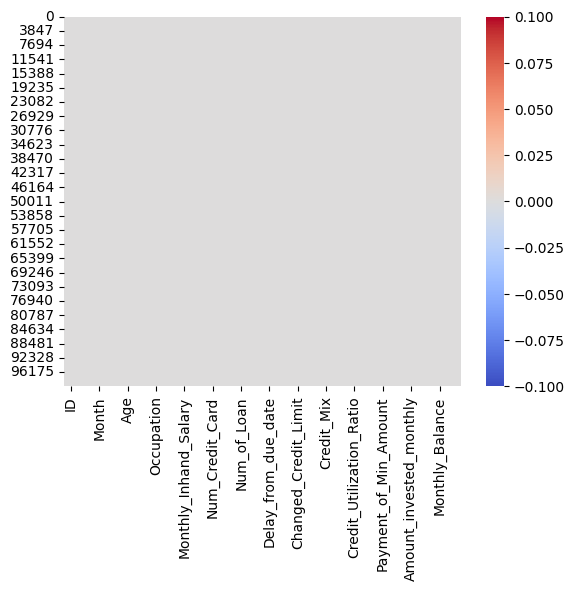

In [ ]:
#visualize missing values
sns.heatmap(df.isnull(), cmap='coolwarm')

In [ ]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [ ]:
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [ ]:
df.nunique()

,0
ID,100000
Customer_ID,12500
Month,8
Name,10128
Age,43
SSN,12500
Occupation,15
Annual_Income,12488
Monthly_Inhand_Salary,13241
Num_Bank_Accounts,12


In [ ]:
#age is being set as flor so lets convert it into int
df['Age']=df['Age'].astype(int)

In [ ]:
#removing outlines in Annual_Income column
Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Annual_Income'] < lower) | (df['Annual_Income'] > upper)]
df = df[(df['Annual_Income'] >= lower) & (df['Annual_Income'] <= upper)]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        98000 non-null  int64  
 1   Customer_ID               98000 non-null  int64  
 2   Month                     98000 non-null  int64  
 3   Name                      98000 non-null  object 
 4   Age                       98000 non-null  int64  
 5   SSN                       98000 non-null  float64
 6   Occupation                98000 non-null  object 
 7   Annual_Income             98000 non-null  float64
 8   Monthly_Inhand_Salary     98000 non-null  float64
 9   Num_Bank_Accounts         98000 non-null  float64
 10  Num_Credit_Card           98000 non-null  float64
 11  Interest_Rate             98000 non-null  float64
 12  Num_of_Loan               98000 non-null  float64
 13  Type_of_Loan              98000 non-null  object 
 14  Delay_from_

In [ ]:
#createing new column income per account
df['Income_per_Account'] = df['Annual_Income'] / df['Num_Bank_Accounts']

In [ ]:
df['Credit_Score_Level'] =df['Credit_Score'].apply(lambda x: 'High' if isinstance(x, int) and x > 700 else 'Low')

In [ ]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


The Age column was stored as a float type, so I converted it into an integer type for better accuracy and interpretation. I also checked for duplicate records, but no duplicates were found in the dataset. While analyzing missing values, I observed that the last nine columns namely (Payment_Behaviour, Monthly_Balance, Credit_Score) contained one null value each. To ensure data consistency and avoid biased analysis, I decided to drop all rows containing null values. After these preprocessing steps, the dataset is now cleaner, with standardized datatypes and no missing or duplicate records, making it ready for further analysis and visualization. Also, we have remomed outliers from our "Annual_Income" column to remove extremely high or low incomes compared to the majority. We have also created two new columns:- 1- Income_per_Account - To represent income per account of an individual if they are having multiple accounts. 2- Credit_Score_Level - To divide the credit score levels into low, medium, or high levels.

###KPIs(Key Perfromance Indicators) Calculation

##customer demographics

In [ ]:
#avergae age
avg_age=df['Age'].mean()
print(f"Average Age of Customers: {avg_age:.2f} years")

Average Age of Customers: 33.27 years


In [ ]:
#Distribution of Occupation
occupation=df['Occupation'].value_counts()
occupation

,count
Occupation,
Lawyer,6960
Engineer,6720
Architect,6672
Mechanic,6648
Scientist,6624
Media_Manager,6600
Developer,6592
Accountant,6576
Teacher,6544


In [ ]:
#Number of Customers by Income Group
max_income = df['Annual_Income'].max()
bins = [0, 25000, 50000, 100000, 200000]
labels = ['Low (<25K)', 'Lower-Middle (25K-50K)',
          'Middle (50K-100K)', 'Upper-Middle (100K-200K)']
if max_income > 200000:
    bins.append(max_income)
    labels.append('High (>200K)')
df['Income_Group'] = pd.cut(df['Annual_Income'], bins=bins, labels=labels, include_lowest=True)

# KPI: Number of customers by income group
income_group_counts = df['Income_Group'].value_counts().sort_index()

print(income_group_counts)


Income_Group
Low (<25K)                  33480
Lower-Middle (25K-50K)      27296
Middle (50K-100K)           26496
Upper-Middle (100K-200K)    10728
Name: count, dtype: int64


###2- Financial Behavior

In [ ]:
avg_annual_income = df['Annual_Income'].mean()
print(f"Average Annual Income: ${avg_annual_income:.2f}")

Average Annual Income: $48146.02


In [ ]:
#Average Monthly In-hand Salary
avg_inhand_salary=df['Monthly_Inhand_Salary'].mean()
print(f"Average in hand montly  Income: ${avg_annual_income:.2f}")


Average in hand montly  Income: $48146.02


In [ ]:
#Average Debt-to-Income Ratio
debt_to_income_ratio = df['Outstanding_Debt'] / df['Annual_Income']
avg_debt_to_income_ratio = debt_to_income_ratio.mean()
print(f"Average Debt-to-Income Ratio: {avg_debt_to_income_ratio:.2f}")


Average Debt-to-Income Ratio: 0.06


In [ ]:
#Average Credit Utilization Ratio
credit_utilization_ratio = df['Credit_Utilization_Ratio']
avg_credit_utilization_ratio = credit_utilization_ratio.mean()
print(f"Average Credit Utilization Ratio: {avg_credit_utilization_ratio:.2f}")

Average Credit Utilization Ratio: 32.22


In [ ]:
#Average Number of Bank Accounts
avg_num_bank_accounts = df['Num_Bank_Accounts'].mean()
print(f"Average Number of Bank Accounts: {avg_num_bank_accounts:.2f}")

Average Number of Bank Accounts: 5.42


In [ ]:
#Average Number of Credit Cards
avg_num_credit_cards = df['Num_Credit_Card'].mean()
print(f"Average Number of Credit Cards: {avg_num_credit_cards:.2f}")

Average Number of Credit Cards: 5.56


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   ID                        98000 non-null  int64   
 1   Customer_ID               98000 non-null  int64   
 2   Month                     98000 non-null  int64   
 3   Name                      98000 non-null  object  
 4   Age                       98000 non-null  int64   
 5   SSN                       98000 non-null  float64 
 6   Occupation                98000 non-null  object  
 7   Annual_Income             98000 non-null  float64 
 8   Monthly_Inhand_Salary     98000 non-null  float64 
 9   Num_Bank_Accounts         98000 non-null  float64 
 10  Num_Credit_Card           98000 non-null  float64 
 11  Interest_Rate             98000 non-null  float64 
 12  Num_of_Loan               98000 non-null  float64 
 13  Type_of_Loan              98000 non-null  object  


###3- Loan & Credit Performance



In [ ]:
#Average Number of Loans per Customer
avg_num_loans = df['Num_of_Loan'].mean()
print(f"Average Number of Loans per Customer: {avg_num_loans:.2f}")

Average Number of Loans per Customer: 3.57


In [ ]:

#Average Interest Rate
avg_interest_rate = df['Interest_Rate'].mean()
print(f"Average Interest Rate: {avg_interest_rate:.2f}%")


Average Interest Rate: 14.69%


In [ ]:

#Total EMI as percentage of Income (EMI Burden Ratio)
total_emi = df['Total_EMI_per_month'].sum()
total_income = df['Annual_Income'].sum()
emi_burden_ratio = (total_emi / total_income) * 100
print(f"Total EMI as % of Income (EMI Burden Ratio): {emi_burden_ratio:.2f}")


Total EMI as % of Income (EMI Burden Ratio): 0.22


In [ ]:

#Average Credit History Age
avg_credit_history_age = df['Credit_History_Age'].mean()
print(f"Average Credit History Age: {avg_credit_history_age:.2f} years")


Average Credit History Age: 219.72 years


###
4-Risk And Fraud Indicators

In [ ]:

#Average Number of Delayed Payments
avg_num_delayed_payments = df['Num_of_Delayed_Payment'].mean()
print(f"Average Number of Delayed Payments: {avg_num_delayed_payments:.2f}")

Average Number of Delayed Payments: 13.46


In [ ]:

#Delay from Due Date(avg, min, max)
avg_delay_from_due_date = df['Num_of_Delayed_Payment'].mean()
min_delay_from_due_date = df['Num_of_Delayed_Payment'].min()
max_delay_from_due_date = df['Num_of_Delayed_Payment'].max()
print(f"Average Delay from Due Date: {avg_delay_from_due_date:.2f}")
print(f"Minimum Delay from Due Date: {min_delay_from_due_date}")
print(f"Maximum Delay from Due Date: {max_delay_from_due_date}")


Average Delay from Due Date: 13.46
Minimum Delay from Due Date: 0.0
Maximum Delay from Due Date: 25.0


In [ ]:
#Percent of Customer with Frequent Credit Inquiries
percent_changed_credit_limit = (df['Changed_Credit_Limit'] > 0).mean() * 100
print(f"Percent of Customers with Changed Credit Limit: {percent_changed_credit_limit:.2f}%")

Percent of Customers with Changed Credit Limit: 100.00%


In [ ]:
#Distribution of Credit Score Categories(Good/Standard/Poor)
credit_score_counts = df['Credit_Score'].value_counts()
print("Distribution of Credit Score Categories:")
print(credit_score_counts)

Distribution of Credit Score Categories:
Credit_Score
Standard    52399
Poor        28678
Good        16923
Name: count, dtype: int64


5-Behavioral Insights

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        98000 non-null  int64  
 1   Customer_ID               98000 non-null  int64  
 2   Month                     98000 non-null  int64  
 3   Name                      98000 non-null  object 
 4   Age                       98000 non-null  int64  
 5   SSN                       98000 non-null  float64
 6   Occupation                98000 non-null  object 
 7   Annual_Income             98000 non-null  float64
 8   Monthly_Inhand_Salary     98000 non-null  float64
 9   Num_Bank_Accounts         98000 non-null  float64
 10  Num_Credit_Card           98000 non-null  float64
 11  Interest_Rate             98000 non-null  float64
 12  Num_of_Loan               98000 non-null  float64
 13  Type_of_Loan              98000 non-null  object 
 14  Delay_from_

In [ ]:
#Distribution of Payment Behaviour
payment_distribution=df['Payment_Behaviour'].value_counts()
payment_distribution

,count
Payment_Behaviour,
Low_spent_Small_value_payments,28436
High_spent_Medium_value_payments,19347
High_spent_Large_value_payments,14097
Low_spent_Medium_value_payments,13980
High_spent_Small_value_payments,11568
Low_spent_Large_value_payments,10572


In [ ]:
#Percent of Customers who pay Minimum Amount only
min_amoung_customer=(df['Payment_Behaviour']=='Low').mean()*100
print(f"Percent of Customers who pay Minimum Amount only: {min_amoung_customer:.2f}%")

Percent of Customers who pay Minimum Amount only: 0.00%


5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

Chart - 1 Number of Customers By Occupation - Bar Chart (Demographic Analysis)

In [ ]:
Occupation_wise_no_of_customers = df['Occupation'].value_counts().reset_index()
Occupation_wise_no_of_customers

,Occupation,count
0,Lawyer,6960
1,Engineer,6720
2,Architect,6672
3,Mechanic,6648
4,Scientist,6624
5,Media_Manager,6600
6,Developer,6592
7,Accountant,6576
8,Teacher,6544
9,Entrepreneur,6496


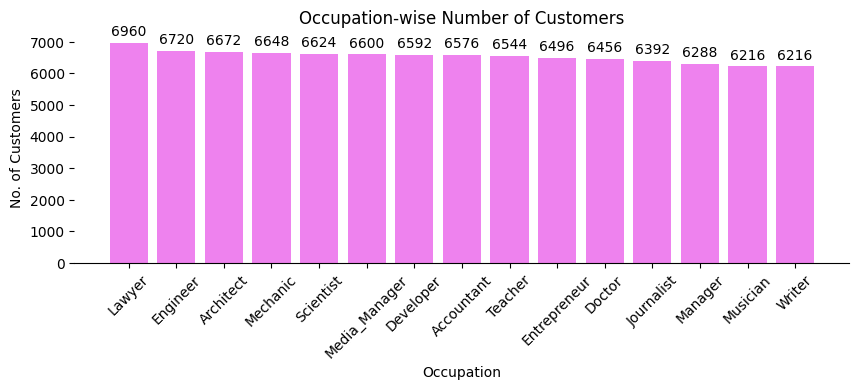

In [ ]:
fig, ax = plt.subplots(figsize=[10,3])

bars = ax.bar(
    x=Occupation_wise_no_of_customers['Occupation'].astype('str'),
    height=Occupation_wise_no_of_customers['count'],
    color="violet"
)

ax.set_xlabel('Occupation')
ax.set_ylabel('No. of Customers')
ax.set_title('Occupation-wise Number of Customers')

ax.spines[['top', 'right', 'left']].set_visible(False)
plt.xticks(rotation=45)

ax.bar_label(bars, padding=3)  # ✅ now works

plt.show()

Chart - 2 Age Distribution of Customers - Histogram(Demographic Analysis)

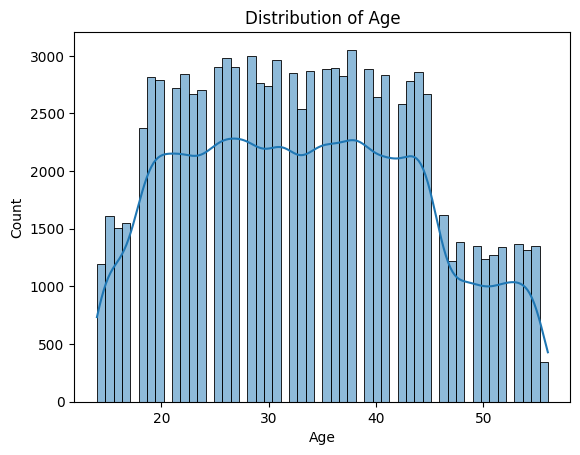

In [ ]:
sns.histplot(df['Age'],kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Chart - 3 Annual Income by Occupation - Boxplot(Demographic Analysis)

In [ ]:
Occupation_wise_income = df.groupby('Occupation')['Annual_Income'].sum().reset_index()
Occupation_wise_income

,Occupation,Annual_Income
0,Accountant,3.141720e+08
1,Architect,3.283849e+08
2,Developer,3.154482e+08
3,Doctor,3.062747e+08
4,Engineer,3.245303e+08
5,Entrepreneur,3.138129e+08
6,Journalist,2.927894e+08
7,Lawyer,3.293012e+08
8,Manager,3.075157e+08
9,Mechanic,3.183117e+08


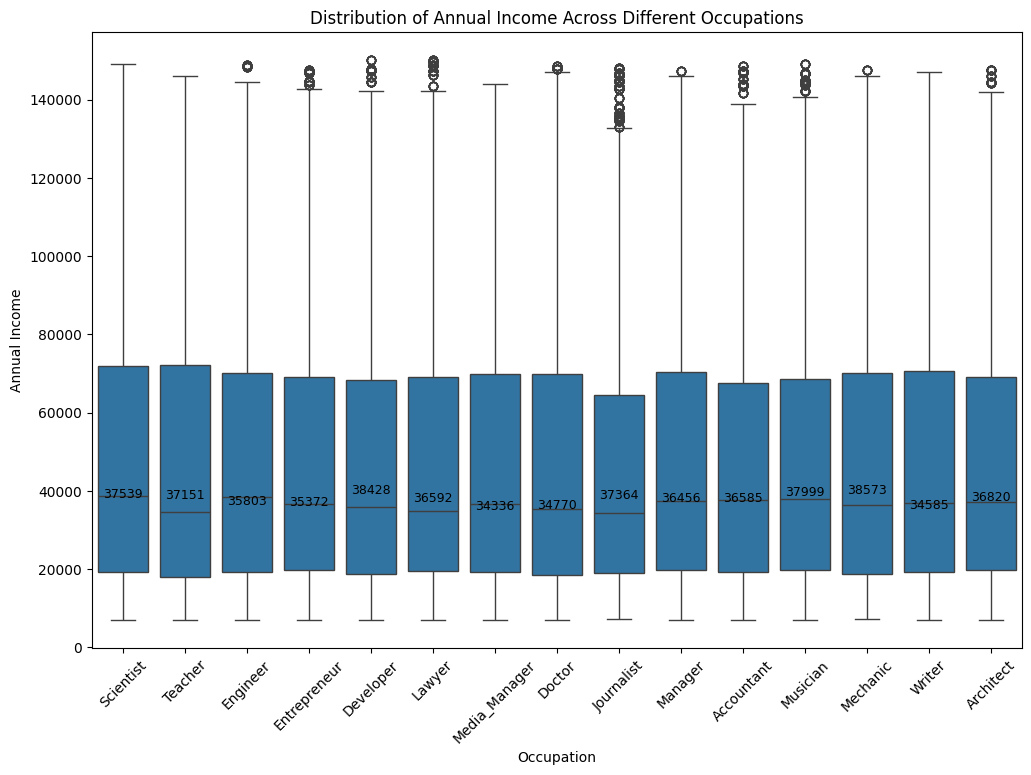

In [ ]:

plt.figure(figsize=(12,8))

ax = sns.boxplot(
    x='Occupation',
    y='Annual_Income',
    data=df
)

# Rotate labels
plt.xticks(rotation=45)

# Titles
plt.title('Distribution of Annual Income Across Different Occupations')
plt.xlabel('Occupation')
plt.ylabel('Annual Income')

# 👉 Calculate medians
medians = df.groupby('Occupation')['Annual_Income'].median()

# 👉 Add median text on plot
for i, occupation in enumerate(medians.index):
    median_value = medians[occupation]
    ax.text(
        i,                     # x position
        median_value,          # y position
        f'{int(median_value)}',# text
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.show()

Chart - 4 Annual Income Distribution - Histogram (Income & Salary Insights)

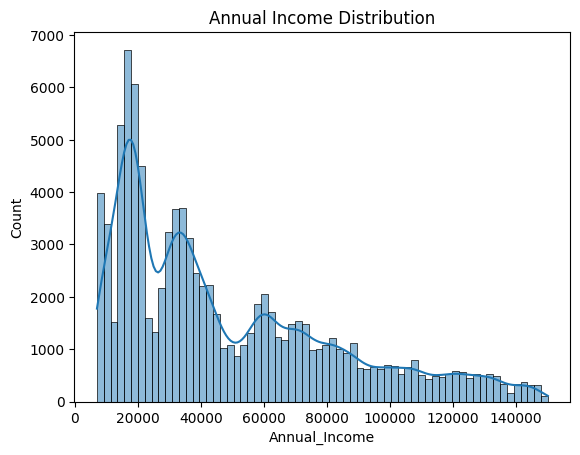

In [ ]:
sns.histplot(df['Annual_Income'],kde=True)
plt.title("Annual Income Distribution")
plt.show()

Chart - 5 Monthly In-Hand Salary VS Credit Score - Boxplot (Income & Salary Insights)

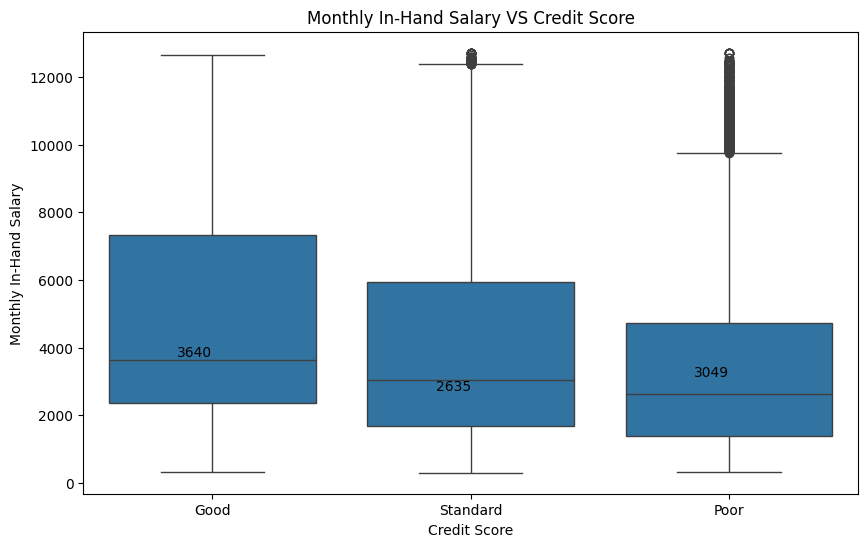

In [ ]:

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Credit_Score', y='Monthly_Inhand_Salary', data=df)

# Calculate medians
medians = df.groupby('Credit_Score')['Monthly_Inhand_Salary'].median()

# Add text labels
for i, value in enumerate(medians):
    ax.text(i, value, f'{int(value)}',
            ha='right', va='bottom', fontsize=10, color='black')

plt.title('Monthly In-Hand Salary VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Monthly In-Hand Salary')

plt.show()

Chart - 6 Comparing Income Distribution of Good VS Poor Credit Score Customers - KDE plot (Income & Salary Insights)

/tmp/ipykernel_589/2217663790.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Credit_Score'] == 'Good']['Annual_Income'],
/tmp/ipykernel_589/2217663790.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Credit_Score'] == 'Poor']['Annual_Income'],


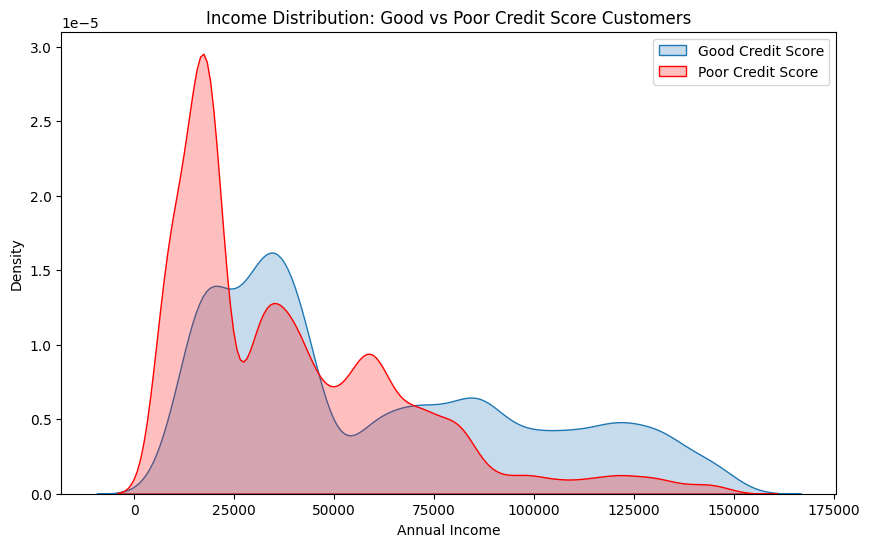

In [ ]:
#Compare Income Distribution of Good VS Poor Credit Score Customers - KDE plot
plt.figure(figsize=(10, 6))

# KDE plot for Good credit score customers
sns.kdeplot(df[df['Credit_Score'] == 'Good']['Annual_Income'],
            label='Good Credit Score', shade=True)

# KDE plot for Poor credit score customers
sns.kdeplot(df[df['Credit_Score'] == 'Poor']['Annual_Income'],
            label='Poor Credit Score', shade=True, color='red')

plt.title("Income Distribution: Good vs Poor Credit Score Customers")
plt.xlabel("Annual Income")
plt.ylabel("Density")
plt.legend()
plt.show()

Chart - 7 Average Number of Loans VS Credit Score - Bar Chart (Credit & Loans Analysis)

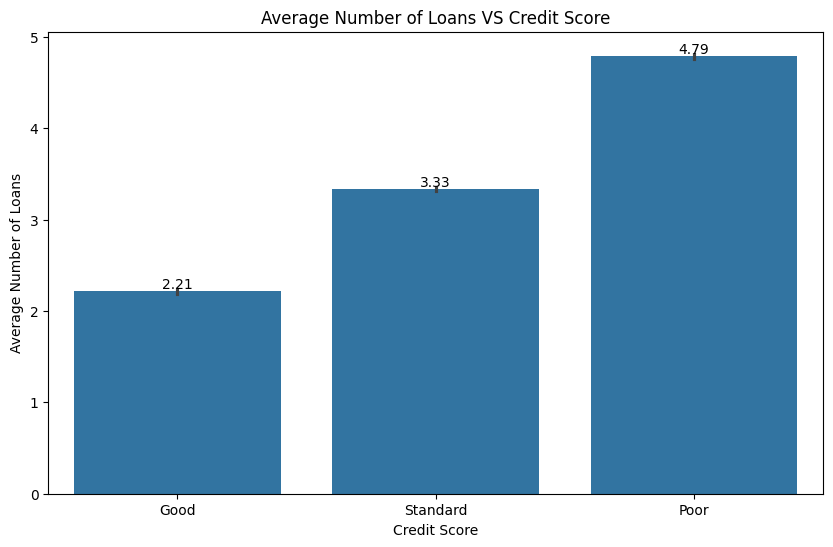

In [ ]:

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Credit_Score', y='Num_of_Loan', data=df)

plt.title('Average Number of Loans VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Average Number of Loans')

# Add labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # x position
        height,                          # y position
        f'{height:.2f}',                 # value (2 decimal places)
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        98000 non-null  int64  
 1   Customer_ID               98000 non-null  int64  
 2   Month                     98000 non-null  int64  
 3   Name                      98000 non-null  object 
 4   Age                       98000 non-null  int64  
 5   SSN                       98000 non-null  float64
 6   Occupation                98000 non-null  object 
 7   Annual_Income             98000 non-null  float64
 8   Monthly_Inhand_Salary     98000 non-null  float64
 9   Num_Bank_Accounts         98000 non-null  float64
 10  Num_Credit_Card           98000 non-null  float64
 11  Interest_Rate             98000 non-null  float64
 12  Num_of_Loan               98000 non-null  float64
 13  Type_of_Loan              98000 non-null  object 
 14  Delay_from_

Chart - 8 Types of Loans Availed by Customers - Stacked Bar Chart (Credit & Loans Analysis)

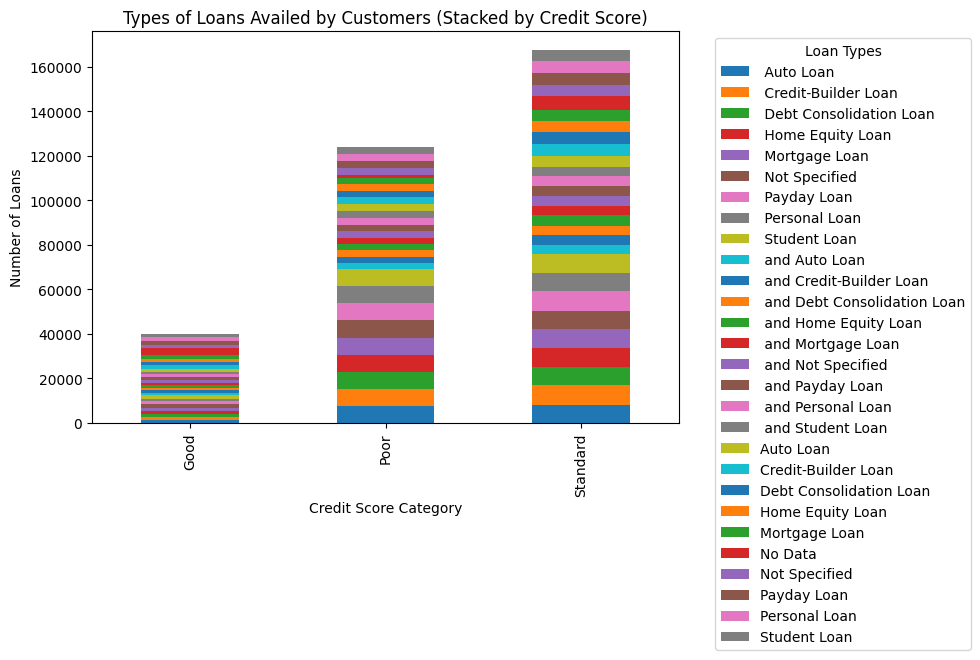

In [ ]:

# Split the Type_of_Loan column (loans are separated by commas)
loan_split = df['Type_of_Loan'].str.get_dummies(sep=',')

# Add Credit Score if you want to analyze loans by score groups
loan_by_score = pd.concat([df['Credit_Score'], loan_split], axis=1)

# Group by Credit Score and sum
loan_distribution = loan_by_score.groupby('Credit_Score').sum()

# Plot stacked bar chart
loan_distribution.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Types of Loans Availed by Customers (Stacked by Credit Score)")
plt.xlabel("Credit Score Category")
plt.ylabel("Number of Loans")
plt.legend(title="Loan Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Chart - 9 Outstanding Debt VS Annual Income(with Credit Score as Color) - Scatter plot (Credit & Loan Analysis)

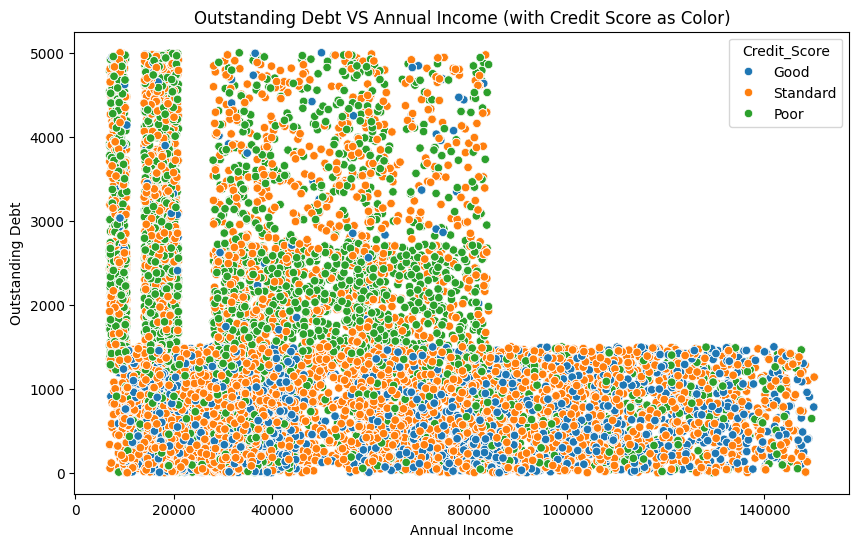

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual_Income', y='Outstanding_Debt', hue='Credit_Score', data=df)
plt.title('Outstanding Debt VS Annual Income (with Credit Score as Color)')
plt.xlabel('Annual Income')
plt.ylabel('Outstanding Debt')
plt.show()

Chart - 10 Number of Delayed Payments VS Credit Score - Box Plot (Risk & Fraud Indicators)

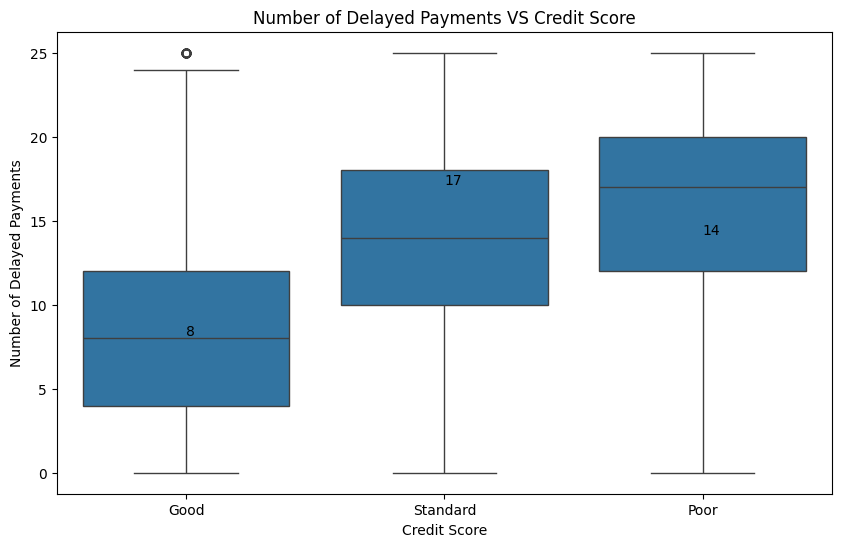

In [ ]:

#Number of Delayed Payments VS Credit Score - Box Plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Credit_Score', y='Num_of_Delayed_Payment', data=df)

# Calculate medians
medians = df.groupby('Credit_Score')['Num_of_Delayed_Payment'].median()

# Add text (numbers)
for i, value in enumerate(medians):
    ax.text(i, value, f'{int(value)}',
            ha='left', va='bottom', fontsize=10, color='black')

plt.title('Number of Delayed Payments VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Delayed Payments')
plt.show()

Chart - 11 Delay From Due Date Distribution - Histogram & KDE plots (Risk & Fraud Indicator)

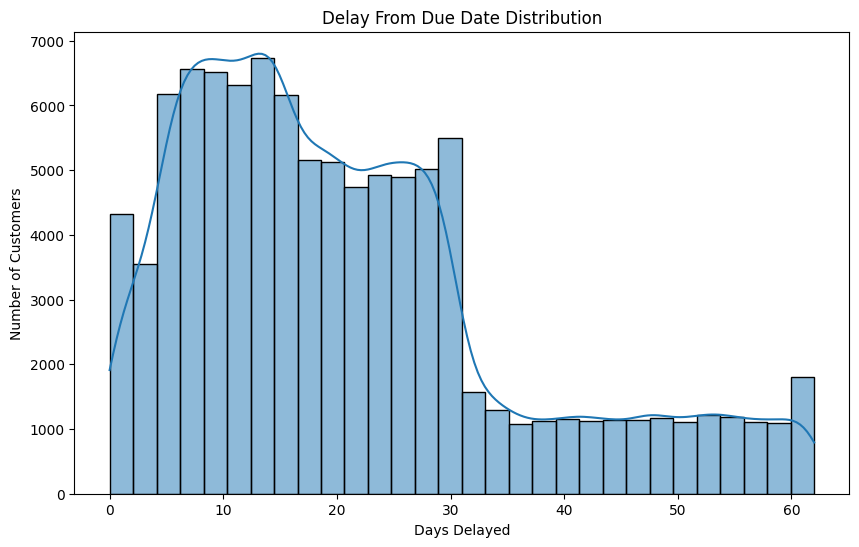

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Delay_from_due_date'], bins=30, edgecolor = 'black', kde=True)
plt.title('Delay From Due Date Distribution')
plt.xlabel('Days Delayed')
plt.ylabel('Number of Customers')
plt.show()

Chart - 12 Credit Utilization Ratio Grouped By Credit Score - Bar Chart (Risk & Fraud Indicators)

<function matplotlib.pyplot.show(close=None, block=None)>

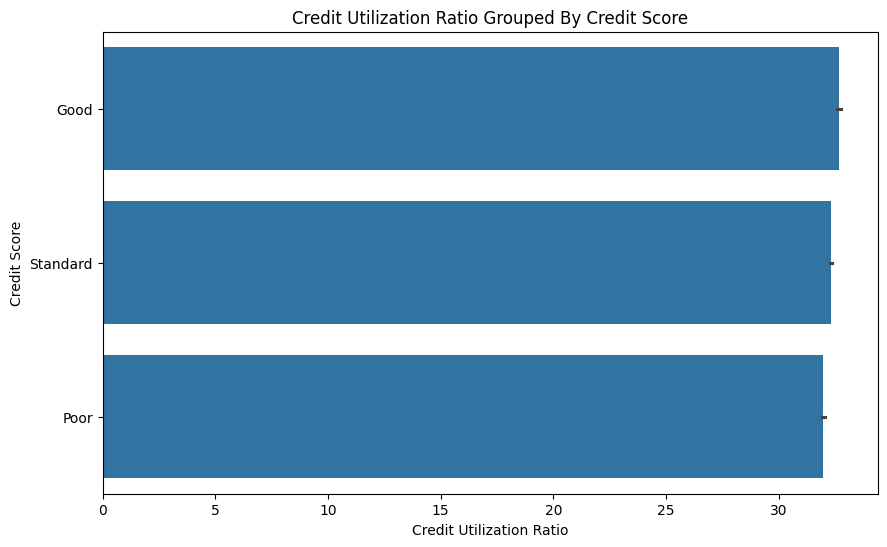

In [11]:

plt.figure(figsize=(10, 6))
sns.barplot(x='Credit_Utilization_Ratio', y='Credit_Score', data=df)
plt.title('Credit Utilization Ratio Grouped By Credit Score')
plt.xlabel('Credit Utilization Ratio')
plt.ylabel('Credit Score')
plt.show

Chart - 13 Correlation Between Numerical Features - Heatmap (Risk & Fraud Indicator)

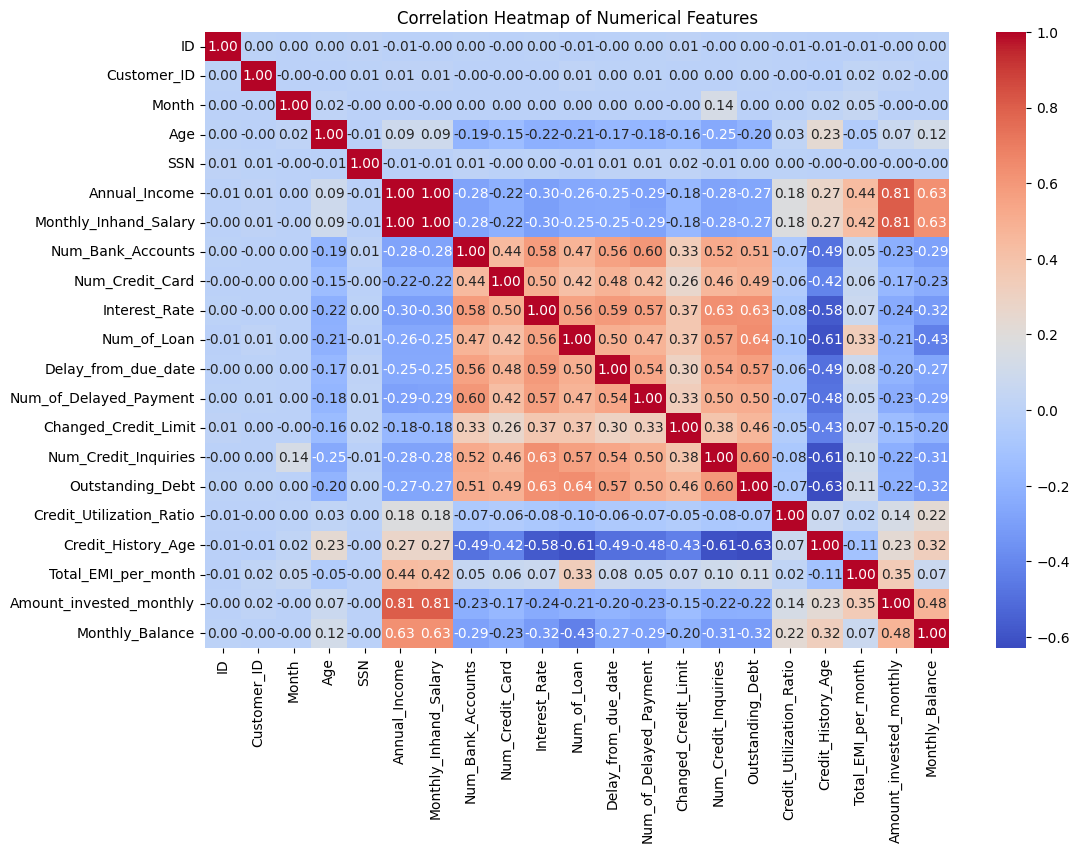

In [12]:

# Select only numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Chart - 14 - Payment Behaviour Distribution - Donut Chart (Behavioural Patterns)

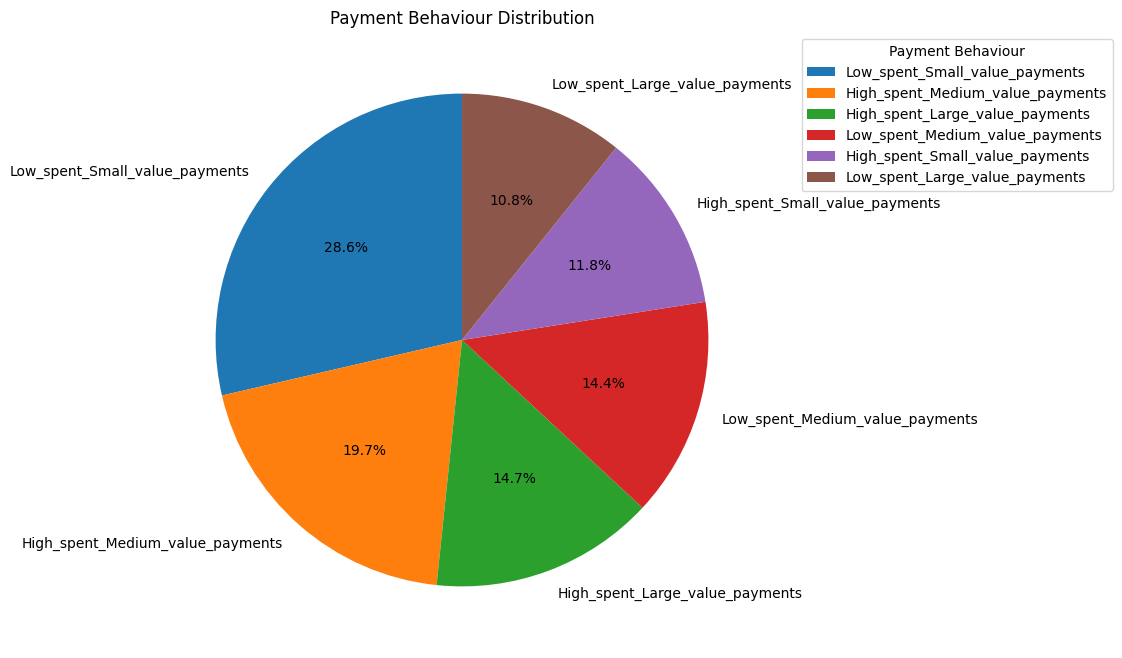

In [16]:
payment_behave=df['Payment_Behaviour'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(payment_behave,labels=payment_behave.index,autopct='%1.1f%%', startangle=90)

payment_behaviour_counts = df['Payment_Behaviour'].value_counts()

plt.title('Payment Behaviour Distribution')


# Add legend
plt.legend(title='Payment Behaviour', bbox_to_anchor=(1.04, 1), loc='upper left')

plt.show()


Chart - 15 - Payment of Minimum Amount(Yes/No) VS Credit Score - Bar Chart (Behavioural Patterns)

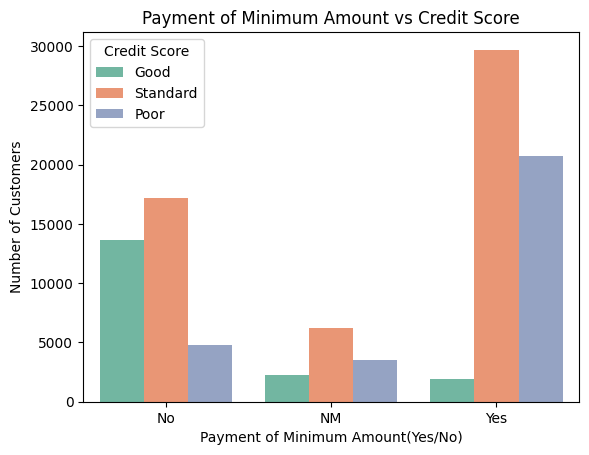

In [17]:
plt.figure9gigsize=(6,6)
sns.countplot(data=df,x='Payment_of_Min_Amount',hue='Credit_Score',palette='Set2')
plt.title("Payment of Minimum Amount vs Credit Score")
plt.xlabel("Payment of Minimum Amount(Yes/No)")
plt.ylabel("Number of Customers")
plt.legend(title="Credit Score")
plt.show()

Chart - 16 - Payment Behaviour VS Occupation - Stacked Bar Chart (Behavioural Patterns)

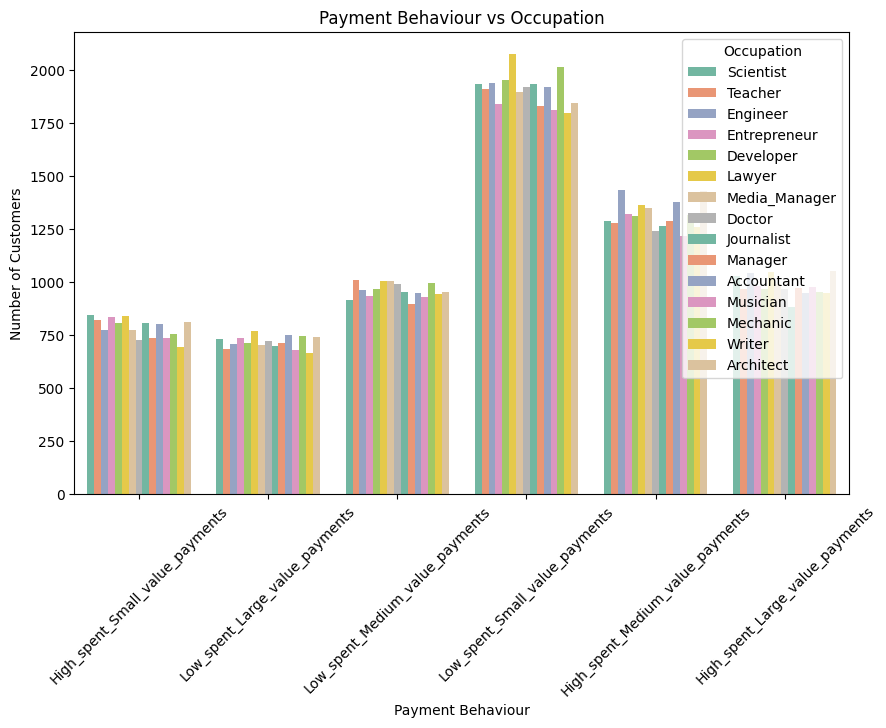

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Payment_Behaviour', hue='Occupation', palette='Set2')
plt.title("Payment Behaviour vs Occupation")
plt.xlabel("Payment Behaviour")
plt.ylabel("Number of Customers")
plt.legend(title="Occupation")
plt.xticks(rotation = 45)
plt.show()

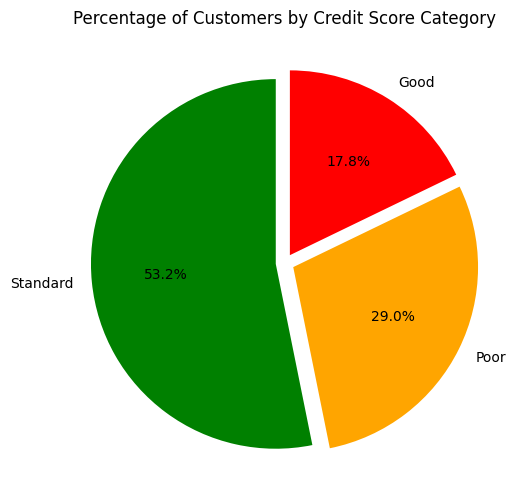

In [20]:


# Count customers in each credit score category
credit_score_counts = df['Credit_Score'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(credit_score_counts,
        labels=credit_score_counts.index,
         autopct='%1.1f%%',
         startangle=90,
        colors=['green', 'orange', 'red'],
        explode=(0.05, 0.05, 0.05))  # slight separation for clarity

plt.title("Percentage of Customers by Credit Score Category")
plt.show()